In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy.linalg as LA

import tensorflow as tf
from tensorflow import keras

import pandas as pd

In [42]:
#load the labeled data and split into train,valid,test sets
df = pd.read_csv('labeled_data.csv')

X = df[['param_0','param_1']].values
y = df[['latent_feature']].values

n = len(X)

test_idx = int(np.floor(n * 0.2))
valid_idx = int(np.floor(n * 0.2) + test_idx)

X_test, X_valid, X_train = X[0:test_idx], X[test_idx:valid_idx], X[valid_idx:]
y_test, y_valid, y_train = y[0:test_idx], y[test_idx:valid_idx], y[valid_idx:]

In [43]:
#Build NN for Classification

num_params = len(X[0])

#build model for predicting parameter stability
param_model = keras.models.Sequential([
    keras.layers.Dense(10, input_dim=num_params),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(rate=0.1),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(rate=0.1),
    keras.layers.Dense(10, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(rate=0.1),
    keras.layers.Dense(num_params, activation='tanh'),
])

opt = keras.optimizers.Adam(learning_rate=0.0001)

param_model.compile(loss='mse', optimizer=opt)

history_param = param_model.fit(X_train, y_train, epochs=200, validation_data=(X_valid, y_valid))

Epoch 1/200
47/47 [==============================] - 2s 9ms/step - loss: 0.7863 - val_loss: 0.2997
Epoch 2/200
47/47 [==============================] - 0s 4ms/step - loss: 0.7305 - val_loss: 0.3232
Epoch 3/200
47/47 [==============================] - 0s 4ms/step - loss: 0.7000 - val_loss: 0.3490
Epoch 4/200
47/47 [==============================] - 0s 8ms/step - loss: 0.6276 - val_loss: 0.3634
Epoch 5/200
47/47 [==============================] - 0s 4ms/step - loss: 0.5687 - val_loss: 0.3675
Epoch 6/200
47/47 [==============================] - 0s 4ms/step - loss: 0.5125 - val_loss: 0.3576
Epoch 7/200
47/47 [==============================] - 0s 5ms/step - loss: 0.4933 - val_loss: 0.3298
Epoch 8/200
47/47 [==============================] - 0s 4ms/step - loss: 0.4629 - val_loss: 0.2954
Epoch 9/200
47/47 [==============================] - 0s 4ms/step - loss: 0.4449 - val_loss: 0.2580
Epoch 10/200
47/47 [==============================] - 0s 4ms/step - loss: 0.4518 - val_loss: 0.2254
Epoch 11/

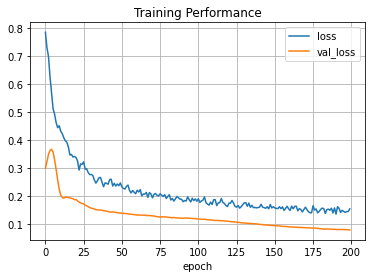

In [44]:
#Plot Training Results
hist_param_df = pd.DataFrame(history_param.history)
hist_param_df.plot()
plt.grid(True)
plt.title('Training Performance')
plt.xlabel('epoch')
plt.show()

In [45]:
#Predict stability based on parameter values
y_pred = param_model.predict(tf.convert_to_tensor(X_test))

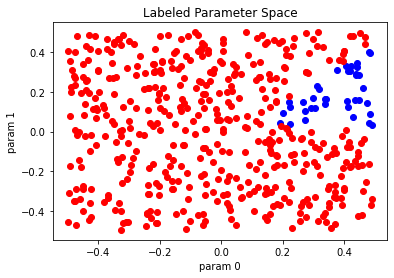

In [53]:
#Visualize predictions

#organize y_pred into 2 classes: 0,1
#0: unstable or questionably stable
#1: stable with confidence
p_thresh = -0.35
class_0_idx = np.where(y_pred[:,1] < p_thresh)
class_1_idx = np.where(y_pred[:,1] >= p_thresh)

class_0_params = np.asarray(X_test)[class_0_idx]
class_1_params = np.asarray(X_test)[class_1_idx]

plt.scatter(class_0_params[:,0], class_0_params[:,1],c='b')
plt.scatter(class_1_params[:,0], class_1_params[:,1],c='r')
plt.xlabel('param 0')
plt.ylabel('param 1')
plt.title('Labeled Parameter Space')

#save figure
#plt.savefig('stability_mapping.png')

plt.show()


In [47]:
#plot true parameter stability region

def predict_stability(x):
    a,b = x[0],x[1]
    A = np.diag([-a,-b,-(a-b)])
    eigs,_ = LA.eig(A)
    eig_idx = np.where(np.real(eigs) <=0)   #this is a tuple
    if len(eig_idx[0]):
        return 1
    else:
        return 0

#min and max parameter values
amin = -0.5
amax = 0.5
bmin = -0.5
bmax = 0.5

#step size of mesh
h = 0.02

xx, yy = np.meshgrid(np.arange(amin, amax, h),
                     np.arange(bmin, bmax, h))

Z = np.zeros(shape=xx.shape)
x_dim,y_dim = Z.shape

for ii in range(0,x_dim):
    for jj in range(0,y_dim):
        x_new = np.array([-xx[ii,jj],-yy[ii,jj]])
        Z[ii,jj] = predict_stability(x_new)

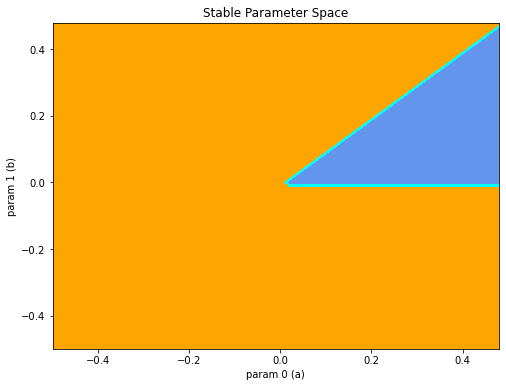

In [67]:
#plot with testing data
cmap_light = ListedColormap(['cornflowerblue', 'cyan', 'orange'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light)
# Plot also the training points
#sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=iris.target_names[y],
#                palette=cmap_light, alpha=1.0, edgecolor="black")

#plt.scatter(class_0_params[:,0], class_0_params[:,1],c='b')
#plt.scatter(class_1_params[:,0], class_1_params[:,1],c='r')

plt.xlabel('param 0 (a)')
plt.ylabel('param 1 (b)')
plt.title('Stable Parameter Space')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

#save figure
plt.savefig('stability_mapping_no_test.png')

plt.show()

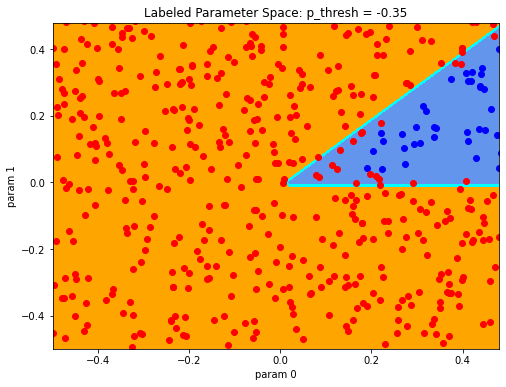

In [65]:
#plot with testing data
cmap_light = ListedColormap(['cornflowerblue', 'cyan', 'orange'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light)
# Plot also the training points
#sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=iris.target_names[y],
#                palette=cmap_light, alpha=1.0, edgecolor="black")

plt.scatter(class_0_params[:,0], class_0_params[:,1],c='b')
plt.scatter(class_1_params[:,0], class_1_params[:,1],c='r')

plt.xlabel('param 0')
plt.ylabel('param 1')
plt.title('Labeled Parameter Space: p_thresh = ' + str(p_thresh))

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

#save figure
plt.savefig('stability_mapping.png')

plt.show()